# Figure 4
Time series of temperature, humidity, and aerosol mass from model output and MOSAiC measurements.

In [1]:
import pandas as pd
import xarray as xr
import datetime as dt
import numpy as np
import utils
import wrfpp
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import glob

# Read measurement data

In [2]:
def read_mosaic_aero_mass(fname, header, species, columns, flag_label, tslice, freq):
    data = pd.read_csv(fname, header=header, sep="\t")
    data["Date/Time"] = pd.to_datetime(data["Date/Time"])
    data = data.set_index("Date/Time").to_xarray()
    data = data.rename(columns)
    data = data.sel(time=tslice)

    data_resample = data.resample(time=freq).mean()
    data_resample = data_resample[species]

    data_masked = data[species].where(data[flag_label]!=1)
    data_masked_resample = data_masked.resample(time=freq).mean()
    
    return data_resample, data_masked_resample

In [3]:
apr = slice(dt.datetime(2020,4,10), dt.datetime(2020,4,20))

ams_columns = {  # used for cleaner column names
    'Date/Time': 'time',
    'Latitude': 'lat',
    'Longitude': 'lon',
    '[SO4]2- [µg/m**3]': 'so4',
    '[NO3]- [µg/m**3]': 'no3',
    '[NH4]+ [µg/m**3]': 'nh4',
    'Cl- [µg/m**3]': 'cl',
    'Org aerosol [µg/m**3]': 'org',
    'QF [NH4]+': 'nh4_qc',  # 1=good, 0=bad
    'Flag pollution': 'pollution_qc'  # 1=polluted, 0=non polluted
}
flag = "pollution_qc"
ams_fname = "/mnt/data/mosaic/AMS_5species_noscaling.tab"
ams_data_1h, ams_masked_1h = read_mosaic_aero_mass(ams_fname, 51, ["so4","org"], ams_columns, flag, apr, "1h")

ebc_columns = {
    'Date/Time': 'time',
    'Latitude': 'lat',
    'Longitude': 'lon',
    'eBC [ng/m**3]': 'ebc',
    'Flag pollution': 'pollution_qc'  # 1=polluted, 0=non polluted
}
ebc_fname = "/mnt/data/mosaic//MOSAiC_eBC.tab"
ebc_data_1h, ebc_masked_1h = read_mosaic_aero_mass(ebc_fname, 42, "ebc", ebc_columns, flag, apr, "1h")


In [4]:
mosaic_met = xr.open_dataset("/mnt/data/mosaic/jozef_lower_atmos/MOSAiC_Atm_Properties.nc")
mosaic_met = mosaic_met.sel(time=apr)

# Read model output

In [5]:
wrfout = xr.open_mfdataset(glob.glob("/mnt/data/model_output/ACI_OPT_2/*_mosaic.nc")).sel(Time=apr)

wrfout["rho_air"] = wrfout.wrf.density_of_dry_air[:]
wrfout["air_temperature"] = wrfout.wrf.air_temperature[:]

/tmp/ipykernel_13887/1121732204.py:1: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'Time' ('Time',) The recommendation is to set join explicitly for this case.
  wrfout = xr.open_mfdataset(glob.glob("/mnt/data/model_output/ACI_OPT_2/*_mosaic.nc")).sel(Time=apr)
/tmp/ipykernel_13887/1121732204.py:1: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  wrfout = xr.open_mfdataset(glob.glob("/mnt/data/model_output/ACI_OPT_2/*_mosaic.

## interpolate from WRF-Chem-Polar aerosol bins to PM1 size range

In [6]:
def make_bin_dimension(ds_wrf, species, nbins=4):
    aname, cwname = species+"_a", species+"_cw"

    # convert a0X output for this species to one array with new bin dimension
    aer_vars = [v for v in ds_wrf.data_vars if aname in v.lower()]
    array_aer = ds_wrf[aer_vars].to_array(dim="bin")
    array_aer["bin"] = np.arange(nbins)

    # cw0X variables
    cld_vars = [v for v in ds_wrf.data_vars if cwname in v.lower()]
    array_cld = ds_wrf[cld_vars].to_array(dim="bin")
    array_cld["bin"] = np.arange(nbins)

    # add new variables to new dataset
    ds_binned = xr.Dataset()
    ds_binned[species] = array_aer+array_cld

    # add bin size coordinates for new dimension
    [dlo, dmid, dhi] = utils.calc_mosaic_size_bins()    
    ds_binned = ds_binned.assign_coords({
        "Dlo": ("bin", dlo),
        "Dmid": ("bin", dmid),
        "Dhi": ("bin", dhi),
        "dD": ("bin", dhi-dlo)
    })

    return ds_binned

def sum_wrf_aero_bins(ds_binned, cutoff=1):
    if "bin" not in ds_binned.dims:
        msg = "[sum_wrf ERROR] no bin dimension on the dataset"
        raise ValueError(msg)
        return
    nbins = len(ds_binned.bin)
    bin_bounds = np.zeros((nbins+1))
    bin_bounds[:-1] = ds_binned.Dlo.values
    bin_bounds[-1] = ds_binned.Dhi.values[-1]

    # find size bin containing cutoff
    i = np.searchsorted(bin_bounds, cutoff)-1

    # sum up to cutoff
    ds_sum = ds_binned.isel(bin=slice(None,i)).sum(dim="bin")

    # add linear fraction of bin containing cutoff
    ibin_width = ds_binned.Dhi.values[i] - ds_binned.Dlo.values[i]
    f = (cutoff - ds_binned.Dlo.values[i]) / ibin_width
    ds_sum += f*ds_binned.isel(bin=i, drop=True)
    
    return ds_sum



In [7]:
wrfout["so4"] = wrfout.rho_air*sum_wrf_aero_bins(make_bin_dimension(wrfout, "so4")).so4
wrfout["bc"] = wrfout.rho_air*sum_wrf_aero_bins(make_bin_dimension(wrfout, "bc")).bc
wrfout["oc"] = wrfout.rho_air*sum_wrf_aero_bins(make_bin_dimension(wrfout, "oc")).oc
wrfout["toa"] = wrfout.rho_air*sum_wrf_aero_bins(make_bin_dimension(wrfout, "totoa")).totoa


In [8]:
wrfout_mosaic_mean = wrfout.mean(["i","j"])
wrfout_mosaic_min = wrfout.min(["i","j"])
wrfout_mosaic_max = wrfout.max(["i","j"])

## Read CESM and CAMS data
Position of Polarstern was extracted in `extract-mosaic-cams.ipynb` and `extract-mosaic-cesm.ipynb`.

In [9]:
cams = xr.open_dataset("/mnt/data/cams/cams_mosaic.nc").sel(time=apr)
cams_mosaic_mean = cams.mean(["i","j"])
cams_mosaic_min = cams.min(["i","j"])
cams_mosaic_max = cams.max(["i","j"])

cesm = xr.open_dataset("/mnt/data/cesm/cesm_mosaic.nc").sel(time=apr)
cesm_mosaic_mean = cesm.mean(["i","j"])
cesm_mosaic_min = cesm.min(["i","j"])
cesm_mosaic_max = cesm.max(["i","j"])

cams_mass_conc_mean = cams_mosaic_mean.interp(time=wrfout.Time) * wrfout_mosaic_mean.rho_air.isel(bottom_top=0)
cams_mass_conc_min = cams_mosaic_min.interp(time=wrfout.Time) * wrfout_mosaic_mean.rho_air.isel(bottom_top=0)
cams_mass_conc_max = cams_mosaic_max.interp(time=wrfout.Time) * wrfout_mosaic_mean.rho_air.isel(bottom_top=0)
cesm_mass_conc_mean = cesm_mosaic_mean.interp(time=wrfout.Time) * wrfout_mosaic_mean.rho_air.isel(bottom_top=0)
cesm_mass_conc_min = cesm_mosaic_min.interp(time=wrfout.Time) * wrfout_mosaic_mean.rho_air.isel(bottom_top=0)
cesm_mass_conc_max = cesm_mosaic_max.interp(time=wrfout.Time) * wrfout_mosaic_mean.rho_air.isel(bottom_top=0)

# make figure

In [10]:
matplotlib.rcParams["font.size"] = 16.0
matplotlib.rcParams["lines.linewidth"] = 2.0
matplotlib.rcParams["axes.linewidth"] = 1.2


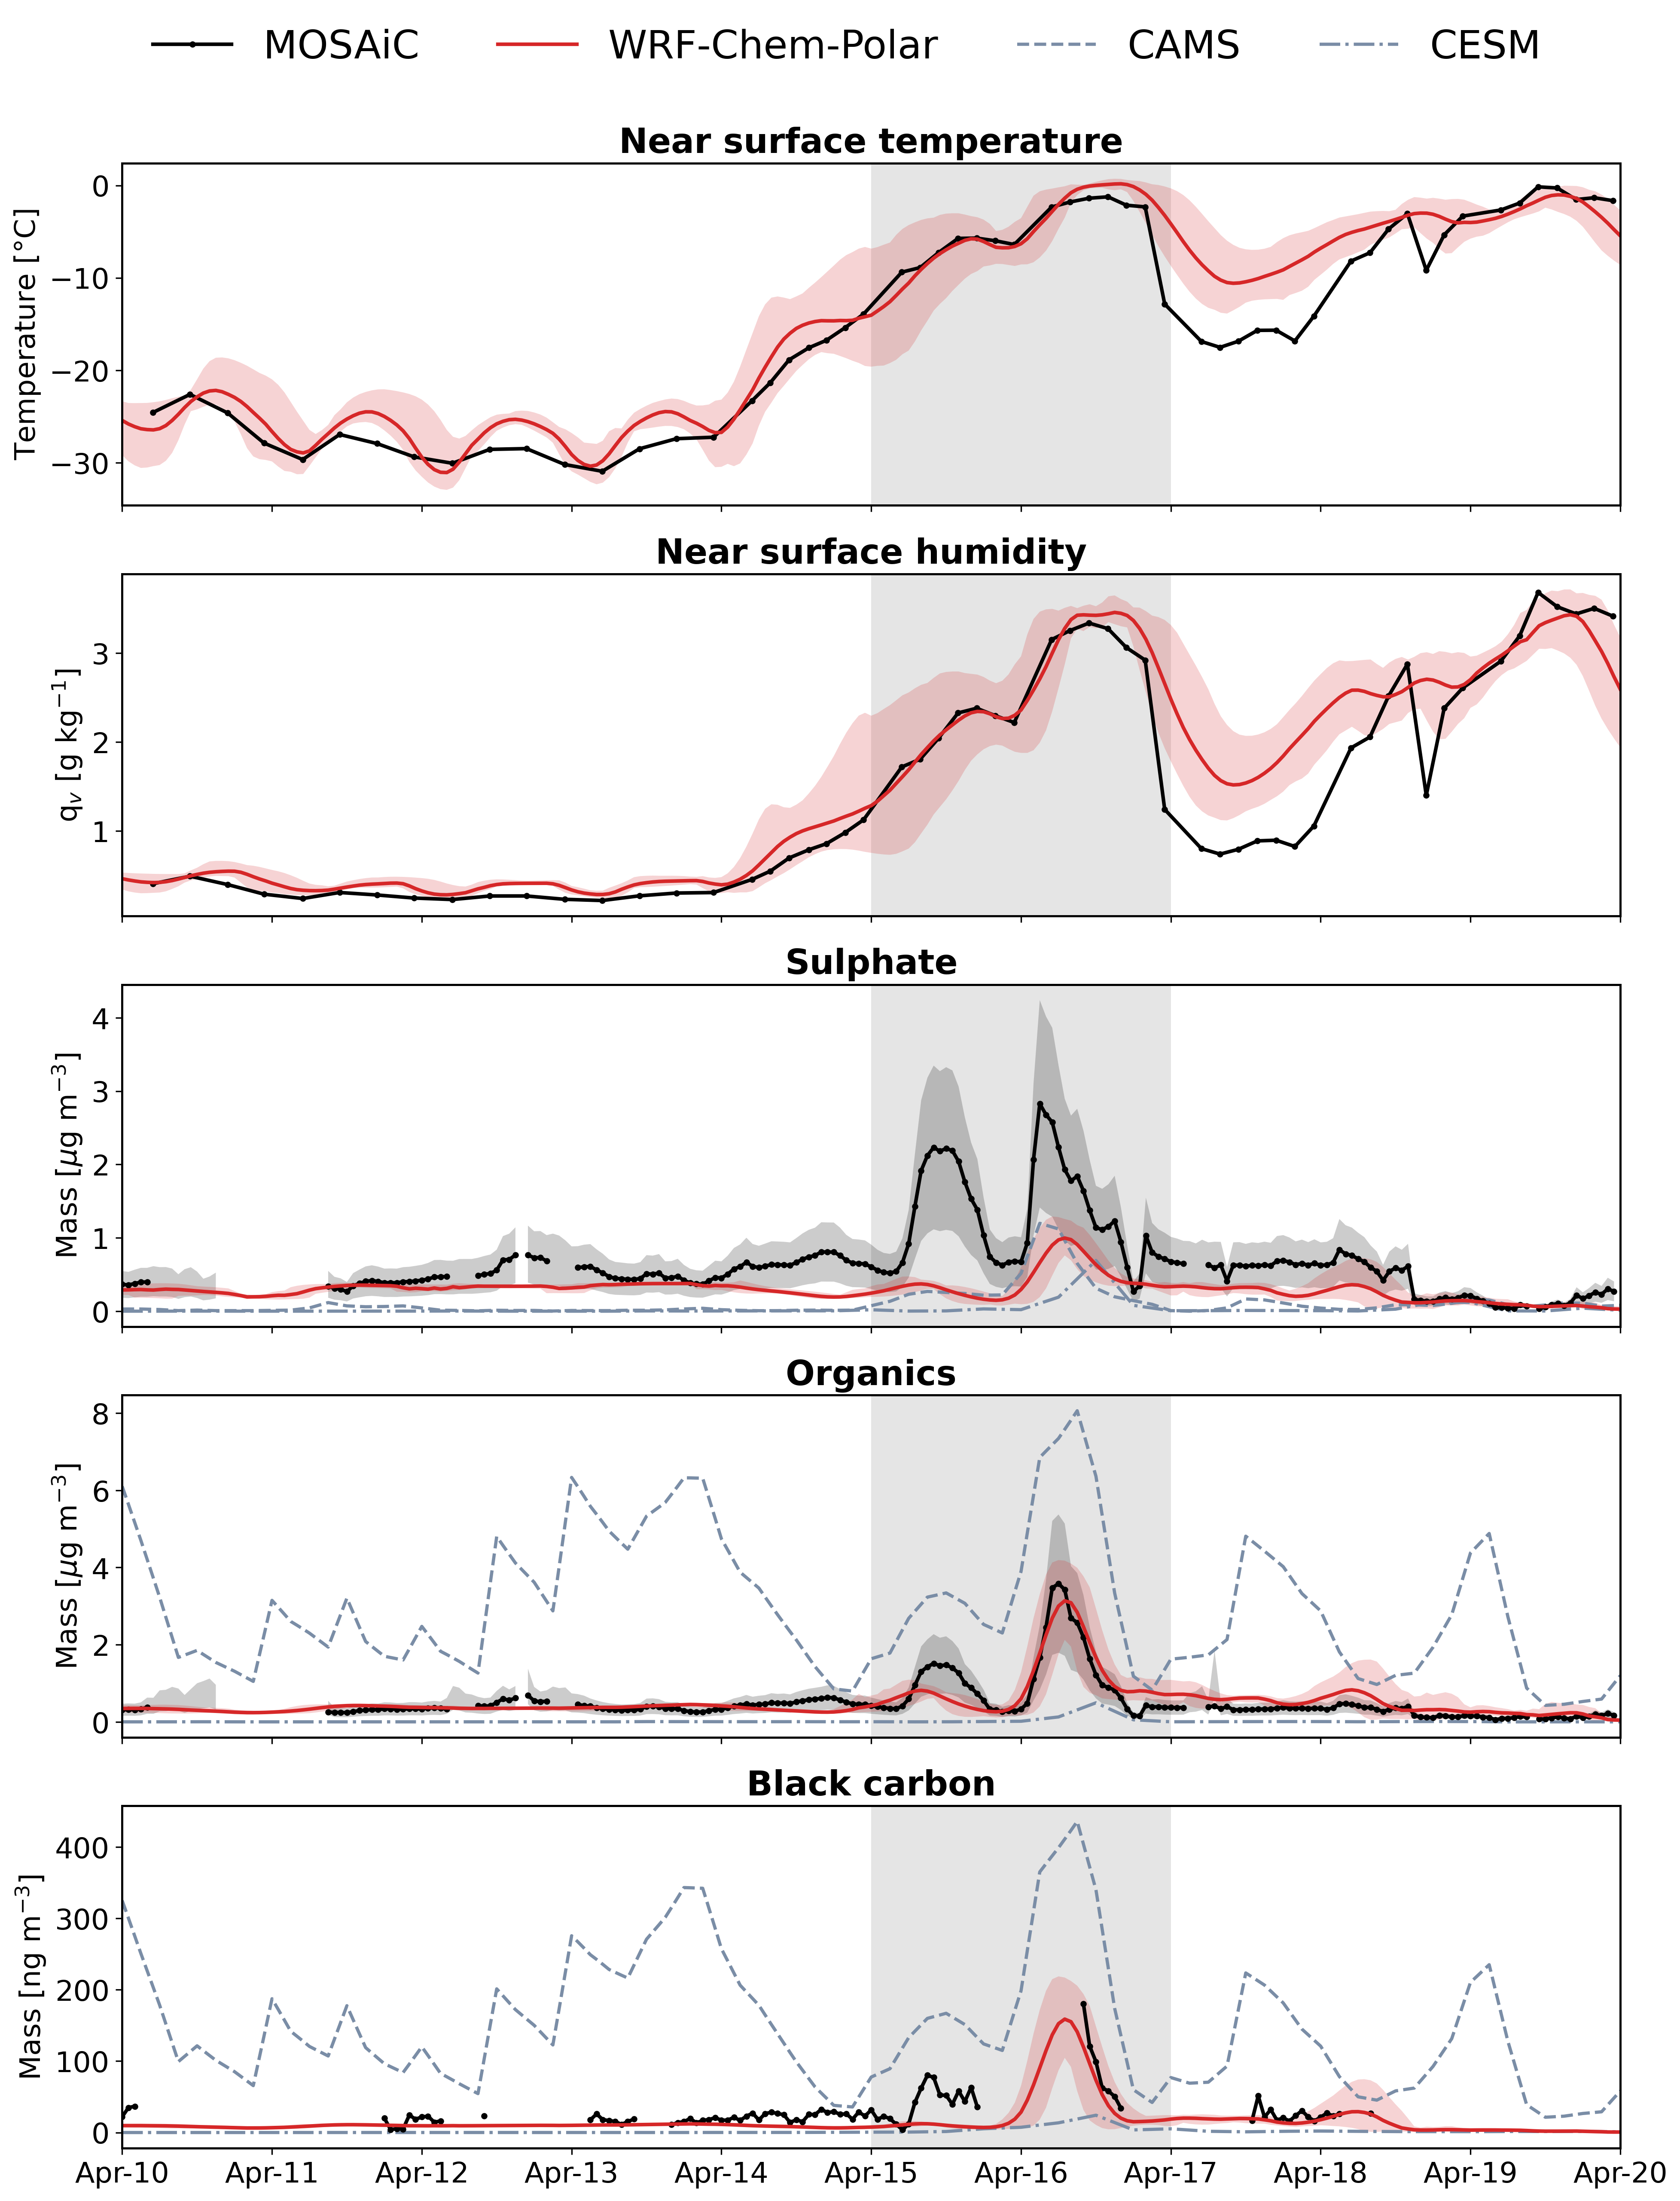

In [17]:
alpha, lw, ms = 0.1, 1.8, 5
c_input_data = "#7A8DA6"


fig, axes = plt.subplots(5, 1, figsize=(15,20), dpi=300)

for ax in axes:
    ax.axvspan(
        dt.datetime(2020,4,15),
        dt.datetime(2020,4,17),
        color="black",
        alpha=0.1,
        ec="None"
    )


### TEMPERATURE

axes[0].plot(
    mosaic_met.time,
    mosaic_met.t_10m,
    "k",
    marker=".",
    ms=ms,
    label="MOSAiC"
)
axes[0].plot(
    wrfout.Time,
    wrfout_mosaic_mean.air_temperature.isel(bottom_top=0)-273.15,
    c="tab:red",
    label="WRF-Chem-Polar"
)
axes[0].fill_between(
    wrfout.Time,
    wrfout_mosaic_min.air_temperature.isel(bottom_top=0)-273.15,
    wrfout_mosaic_max.air_temperature.isel(bottom_top=0)-273.15,
    color="tab:red",
    alpha=0.2,
    edgecolor="None"
)
axes[0].set_ylabel("Temperature [$\\degree$C]")
axes[0].set_title("Near surface temperature", weight="bold")


### HUMIDITY

axes[1].plot(
    mosaic_met.time,
    mosaic_met.r_10m,
    "k",
    marker=".",
    ms=ms
)
axes[1].plot(
    wrfout.Time,
    wrfout_mosaic_mean.QVAPOR.isel(bottom_top=0)*1e3,
    c="tab:red",
)
axes[1].fill_between(
    wrfout.Time,
    wrfout_mosaic_min.QVAPOR.isel(bottom_top=0)*1e3,
    wrfout_mosaic_max.QVAPOR.isel(bottom_top=0)*1e3,
    color="tab:red",
    alpha=0.2,
    edgecolor="None"
)
axes[1].set_ylabel("q$_v$ [g kg$^{{-1}}$]")
axes[1].set_title("Near surface humidity", weight="bold")


### AEROSOL MASS
f_ams = 0.65
std_ams = 0.5

# sulphate
lcams, = axes[2].plot(
    wrfout.Time,
    1e9*cams_mass_conc_mean.so4,
    c=c_input_data,
    ls="dashed",
    label="CAMS",
    linewidth=lw,
)
lcesm, = axes[2].plot(
    wrfout.Time,
    1e9*cesm_mass_conc_mean.so4.isel(lev=-1),
    c=c_input_data,
    ls="dashdot",
    label="CESM",
    linewidth=lw
)
axes[2].fill_between(
    ams_masked_1h.time,
    f_ams*ams_data_1h.so4-std_ams*f_ams*ams_data_1h.so4,
    f_ams*ams_data_1h.so4+std_ams*f_ams*ams_data_1h.so4,
    color="k",
    alpha=0.2,
    edgecolor="None"
)
lmosaic, = axes[2].plot(
    ams_masked_1h.time,
    f_ams*ams_masked_1h.so4,
    'k',
    label='MOSAiC',
    marker=".",
    ms=ms
)
lwrf, = axes[2].plot(
    wrfout.Time,
    wrfout_mosaic_mean.so4.isel(bottom_top=0),
    c="tab:red",
    label="WRF-Chem-Polar"
)
axes[2].fill_between(
    wrfout.Time,
    wrfout_mosaic_min.so4.isel(bottom_top=0),
    wrfout_mosaic_max.so4.isel(bottom_top=0),
    color="tab:red",
    alpha=0.2,
    edgecolor="None"
)
axes[2].set_ylabel("Mass [$\\mu$g m$^{{-3}}$]")
axes[2].set_title("Sulphate", weight="bold")

# oc
axes[3].plot(
    wrfout.Time,
    1e9*(cams_mass_conc_mean.oc_hydrophilic+cams_mass_conc_mean.oc_hydrophobic),
    c=c_input_data,
    ls="dashed",
    linewidth=lw,
    label="CAMS hydrophilic+hydrophobic"
)
axes[3].plot(
    wrfout.Time,
    1e9*cesm_mass_conc_mean.oc.isel(lev=-1),
    c=c_input_data,
    ls="dashdot",
    linewidth=lw,
)
axes[3].fill_between(
    ams_masked_1h.time,
    f_ams*ams_data_1h.org-std_ams*f_ams*ams_data_1h.org,
    f_ams*ams_data_1h.org+std_ams*f_ams*ams_data_1h.org,
    color="k",
    alpha=0.2,
    edgecolor="None"
)
axes[3].plot(
    ams_masked_1h.time,
    f_ams*ams_masked_1h.org,
    'k',
    marker=".",
    ms=ms
)
axes[3].fill_between(
    wrfout.Time,
    (wrfout_mosaic_min.toa+wrfout_mosaic_min.oc).isel(bottom_top=0),
    (wrfout_mosaic_max.toa+wrfout_mosaic_max.oc).isel(bottom_top=0),
    color="tab:red",
    alpha=0.2,
    edgecolor="None"
)
axes[3].plot(
    wrfout.Time,
    (wrfout_mosaic_mean.toa+wrfout_mosaic_mean.oc).isel(bottom_top=0),
    c="tab:red",
    label="WFR-Chem-Polar"
)
axes[3].set_ylabel("Mass [$\\mu$g m$^{{-3}}$]")
axes[3].set_title("Organics", weight="bold")

# bc

axes[4].plot(
    wrfout.Time,
    1e12*(cams_mass_conc_mean.bc_hydrophilic+cams_mass_conc_mean.bc_hydrophobic),
    c=c_input_data,
    label="CAMS all",
    ls="dashed",
    linewidth=lw
)
axes[4].plot(
    wrfout.Time,
    1e12*cesm_mass_conc_mean.bc.isel(lev=-1),
    c=c_input_data,
    ls="dashdot",
    linewidth=lw
)
axes[4].plot(
    ebc_masked_1h.time,
    f_ams*ebc_masked_1h,
    'k',
    marker=".",
    ms=ms
)
axes[4].plot(
    wrfout.Time,
    wrfout_mosaic_mean.bc.isel(bottom_top=0)*1e3,
    c="tab:red",
    label="WRF-Chem-Polar"
)
axes[4].fill_between(
    wrfout.Time,
    wrfout_mosaic_min.bc.isel(bottom_top=0)*1e3,
    wrfout_mosaic_max.bc.isel(bottom_top=0)*1e3,
    color="tab:red",
    alpha=0.2,
    edgecolor="None"
)
axes[4].set_ylabel("Mass [ng m$^{{-3}}$]")
axes[4].set_title("Black carbon", weight="bold")

fig.legend(
    ncols=4,
    handles=[lmosaic,lwrf,lcams,lcesm],
    loc="center",
    bbox_to_anchor=(0, 0.9, 1, 0.05),
    edgecolor="None",
    borderaxespad=0.25,
    fontsize=22
)
for ax in axes:
    ax.set_xlim(apr.start, apr.stop)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b-%d"))
for ax in axes[:-1]:
    ax.set_xticklabels([])

plt.savefig(f"../figures/figure4.png", bbox_inches="tight")


## statistics of background and event

In [ ]:
bg = slice(dt.datetime(2020,4,10), dt.datetime(2020,4,14,23,59))
wai = slice(dt.datetime(2020,4,15), dt.datetime(2020,4,16,23,59))

ams_bg = ams_masked_1h.sel(time=bg)
ams_wai = ams_masked_1h.sel(time=wai)
print(f"AMS bg. medians: so4 = {ams_bg.median().so4.values:.2f}, org={ams_bg.median().org:.2f}")
print(f"AMS bg. means:   so4 = {ams_bg.mean().so4.values:.2f}, org={ams_bg.mean().org:.2f}")
print()
print(f"AMS WAI medians: so4 = {ams_wai.median().so4.values:.2f}, org={ams_wai.median().org:.2f}")
print(f"AMS WAI means:   so4 = {ams_wai.mean().so4.values:.2f}, org={ams_wai.mean().org:.2f}")
print()

ebc_bg = ebc_masked_1h.sel(time=bg)
ebc_wai = ebc_masked_1h.sel(time=wai)
print(f"eBC bg. median: {ebc_bg.median().values:.2f}")
print(f"eBC bg. mean:   {ebc_bg.mean().values:.2f}")
print()
print(f"eBC WAI median: {ebc_wai.median().values:.2f}")
print(f"eBC WAI mean:   {ebc_wai.mean().values:.2f}")
print()

wrf_bg = wrfout_mosaic_mean.sel(Time=bg).isel(bottom_top=0).load()
wrf_wai = wrfout_mosaic_mean.sel(Time=wai).isel(bottom_top=0).load()
print(f"WRF bg. medians: so4 = {wrf_bg.so4.median().values:.2f}, org={wrf_bg.oc.median():.2f}, bc={wrf_bg.bc.median():.2f}")
print(f"WRF bg. means:   so4 = {wrf_bg.so4.mean().values:.2f}, org={wrf_bg.oc.mean():.2f}, bc={wrf_bg.bc.mean():.2f}")
print()
print(f"WRF WAI medians: so4 = {wrf_wai.so4.median().values:.2f}, org={wrf_wai.oc.median():.2f}, bc={wrf_wai.bc.median():.2f}")
print(f"WRF WAI means:   so4 = {wrf_wai.so4.mean().values:.2f}, org={wrf_wai.oc.mean():.2f}, bc={wrf_wai.bc.mean():.2f}")
print()



In [ ]:
wai15 = slice(dt.datetime(2020,4,15), dt.datetime(2020,4,15,23,59))
wai16 = slice(dt.datetime(2020,4,16), dt.datetime(2020,4,16,23,59))

ams_15 = ams_masked_1h.sel(time=wai15)
ams_16 = ams_masked_1h.sel(time=wai16)
print(f"AMS bg. medians: so4 = {ams_bg.median().so4.values:.2f}, org={ams_bg.median().org:.2f}")
print(f"AMS bg. means:   so4 = {ams_bg.mean().so4.values:.2f}, org={ams_bg.mean().org:.2f}")
print()
print(f"AMS 15 medians: so4 = {ams_15.median().so4.values:.2f}, org={ams_15.median().org:.2f}")
print(f"AMS 15 means:   so4 = {ams_15.mean().so4.values:.2f}, org={ams_15.mean().org:.2f}")
print()
print(f"AMS 16 medians: so4 = {ams_16.median().so4.values:.2f}, org={ams_16.median().org:.2f}")
print(f"AMS 16 means:   so4 = {ams_16.mean().so4.values:.2f}, org={ams_16.mean().org:.2f}")
print()

ebc_15 = ebc_masked_1h.sel(time=wai15)
ebc_16 = ebc_masked_1h.sel(time=wai16)
print(f"eBC bg. median: {ebc_bg.median().values:.2f}")
print(f"eBC bg. mean:   {ebc_bg.mean().values:.2f}")
print()
print(f"eBC 15 median: {ebc_15.median().values:.2f}")
print(f"eBC 15 mean:   {ebc_15.mean().values:.2f}")
print()
print(f"eBC 16 median: {ebc_16.median().values:.2f}")
print(f"eBC 16 mean:   {ebc_16.mean().values:.2f}")
print()

wrf_15 = wrfout_mosaic_mean.sel(Time=wai15).isel(bottom_top=0).load()
wrf_16 = wrfout_mosaic_mean.sel(Time=wai16).isel(bottom_top=0).load()
print(f"WRF bg. medians: so4 = {wrf_bg.so4.median().values:.2f}, org={wrf_bg.oc.median():.2f}, bc={wrf_bg.bc.median():.2f}")
print(f"WRF bg. means:   so4 = {wrf_bg.so4.mean().values:.2f}, org={wrf_bg.oc.mean():.2f}, bc={wrf_bg.bc.mean():.2f}")
print()
print(f"WRF 15 medians: so4 = {wrf_15.so4.median().values:.2f}, org={wrf_15.oc.median():.2f}, bc={wrf_15.bc.median():.2f}")
print(f"WRF 15 means:   so4 = {wrf_15.so4.mean().values:.2f}, org={wrf_15.oc.mean():.2f}, bc={wrf_15.bc.mean():.2f}")
print()
print(f"WRF 16 medians: so4 = {wrf_16.so4.median().values:.2f}, org={wrf_16.oc.median():.2f}, bc={wrf_16.bc.median():.2f}")
print(f"WRF 16 means:   so4 = {wrf_16.so4.mean().values:.2f}, org={wrf_16.oc.mean():.2f}, bc={wrf_16.bc.mean():.2f}")
print()

